# Agentic forecasting step-by-step

**skforecast-ai** is an **AI forecasting assistant** that pairs a deterministic engine, powered by [**skforecast**](https://skforecast.org), with an **LLM reasoning layer**. Simply provide a time series, and the assistant automatically profiles the data, selects a model using established best practices, and evaluates its performance. It returns both the final forecast and the runnable skforecast script that produced it.

This tutorial walks through the **step-by-step path**: the approach for users who want granular control to inspect or adjust intermediate decisions before committing to a full run. If you prefer a single-call workflow that returns results immediately, see the [fast-path tutorial](./agentic-forecasting.html).

Both paths share the same deterministic engine and produce identical results and reproducible `skforecast` code. The step-by-step path gives you three additional capabilities:

+ **Inspect intermediate objects**: examine the `ForecastingProfile` and `ForecastPlan` before any model is trained, and confirm the assistant's recommendations make sense for your domain.

+ **Override any single decision**: change the estimator, lags, window features, or preprocessing without re-running the entire pipeline from scratch. Pass the modified plan directly to `forecast()` or `backtest()`.

+ **Reuse the profile and plan across branches**: build the profile and plan once, then run `forecast()` for future predictions, `backtest()` for historical evaluation, and `compare()` to rank several candidate configurations: each reusing the same profile, with no redundant profiling.

The `ask()` method is available at every stage. It interprets what you pass to it (a profile, a plan, a generated script, a cross-validation strategy, a forecast result, a backtest result, or a comparison result), but it never executes the workflow or silently changes any recommendation.

<div style="box-sizing:border-box; margin:16px 0; font-family:-apple-system,Segoe UI,Roboto,Helvetica,Arial,sans-serif; color:#24292f; max-width:100%;">
  <div style="box-sizing:border-box; display:flex; gap:20px; flex-wrap:wrap; align-items:stretch;">

<!-- Fast path -->
<div style="box-sizing:border-box; flex:1 1 260px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#0969da; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Fast path: one call</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Profiling, planning and execution happen internally.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:18px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dbeafe; border:1px solid #0969da; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

<!-- Step-by-step path -->
<div style="box-sizing:border-box; flex:1.6 1 340px; min-width:0; border:1px solid #d0d7de; border-radius:12px; overflow:hidden; display:flex; flex-direction:column;">
    <div style="box-sizing:border-box; background:#1a7f37; color:#ffffff; padding:12px 16px; font-size:15px; font-weight:700;">Step-by-step path: full control</div>
    <div style="box-sizing:border-box; padding:16px; background:#f6f8fa; flex:1;">
    <p style="margin:0 0 12px 0; font-size:13px;">Build a <code>profile</code> and a <code>plan</code> from your data, then branch into forecasting and backtesting.</p>
    <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:8px 12px; text-align:center; font-weight:600;">data</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">profile()</div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px 12px; text-align:center; font-weight:700;">plan()<br><span style="font-weight:400; font-size:12px; color:#57606a;">refine_plan(), optional (Deterministic or Agentic mode)</span></div>
    <div style="text-align:center; color:#57606a; font-size:16px; line-height:1.4;">&#8595;</div>
    <div style="box-sizing:border-box; display:flex; gap:12px; flex-wrap:wrap;">
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Forecast</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">forecast()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or forecast_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">predictions + code</div>
        </div>
        <div style="box-sizing:border-box; flex:1 1 150px; min-width:0; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px;">
        <div style="font-size:11px; color:#57606a; text-transform:uppercase; letter-spacing:.5px; text-align:center; margin-bottom:6px;">Backtesting (validation)</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">create_cv()<br><span style="font-weight:400; font-size:12px; color:#57606a;">Deterministic, Agentic mode</span><br><span style="font-weight:400; font-size:12px; color:#57606a;">or pass a skforecast TimeSeriesFold object</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="box-sizing:border-box; background:#dcfce7; border:1px solid #1a7f37; border-radius:8px; padding:8px; text-align:center; font-weight:700;">backtest()<br><span style="font-weight:400; font-size:12px; color:#57606a;">or backtest_code()</span></div>
        <div style="text-align:center; color:#57606a; font-size:15px; line-height:1.4;">&#8595;</div>
        <div style="text-align:center; font-size:12px; color:#24292f;">metrics + predictions + code</div>
        </div>
    </div>
    </div>
</div>

</div>

  <!-- compare() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #bc4c00; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#bc4c00; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">Model selection: which forecaster should you use?</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#fff4ed; font-size:13px;">
      <p style="margin:0 0 12px 0;"><code>compare()</code> answers the question every forecasting project starts with: <b>Among several reasonable models, which one actually performs best on my data?</b> Every candidate is evaluated using the same data and cross-validation strategy. Therefore, the differences you see come from the models, not from the setup.</p>
      <table style="width:100%; border:0; border-collapse:collapse; table-layout:fixed; background:transparent; box-shadow:none; margin:0;">
        <tbody style="border:0; background:transparent;">
        <tr style="border:0; background:transparent;">
          <td style="width:28%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:600;">Candidates</span><br><span style="font-size:12px; color:#57606a;">A handful of configurations worth testing: different forecasters, estimators, lags or window features. Supply your own, or let the data profile propose them.</span></div>
          </td>
          <td style="width:5%; border:0; background:transparent; vertical-align:middle; text-align:center; color:#57606a; font-size:18px; padding:0;">&#8594;</td>
          <td style="width:34%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffe0cc; border:1px solid #bc4c00; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:700;">compare()</span><br><span style="font-size:12px; color:#57606a;">Runs a full backtest for each candidate under identical conditions, and scores them with the metrics you care about.</span></div>
          </td>
          <td style="width:5%; border:0; background:transparent; vertical-align:middle; text-align:center; color:#57606a; font-size:18px; padding:0;">&#8594;</td>
          <td style="width:28%; border:0; background:transparent; vertical-align:middle; padding:0;">
            <div style="box-sizing:border-box; background:#ffffff; border:1px solid #d0d7de; border-radius:8px; padding:10px 12px; text-align:center; font-size:13px;"><span style="font-weight:600;">A ranked answer</span><br><span style="font-size:12px; color:#57606a;">A leaderboard sorted best to worst, the reproducible code behind every row, and the winner ready to be used for forecasting or further tuning.</span></div>
          </td>
        </tr>
        </tbody>
      </table>
      <p style="margin:12px 0 0 0; font-size:12px; color:#57606a; text-align:center;">The ranking is a plain sort of the metric column: fully deterministic and auditable. The LLM plays no part in choosing the winner.</p>
    </div>
  </div>

  <!-- ask() banner -->
  <div style="box-sizing:border-box; margin-top:16px; border:1px solid #8250df; border-radius:12px; overflow:hidden;">
    <div style="box-sizing:border-box; background:#8250df; color:#ffffff; padding:10px 16px; font-size:15px; font-weight:700;">LLM reasoning: available at any moment, in any workflow</div>
    <div style="box-sizing:border-box; padding:12px 16px; background:#faf5ff; font-size:13px;">Call <code>ask()</code> before, during or after either path. It can take a <code>profile</code> (optionally with a <code>plan</code>), a generated script (from <code>forecast_code()</code> or <code>backtest_code()</code>), a cross-validation strategy (from <code>create_cv()</code>), a result (from <code>forecast()</code>, <code>backtest()</code> or <code>compare()</code>), or nothing at all (pure Q&amp;A).</div>
  </div>
</div>

The following example walks through the **step-by-step path**, allowing users to understand and control what happens under the hood. If you prefer the quickest way to go from raw data to a validated forecast with minimal setup, visit the [fast-path tutorial](./agentic-forecasting.html).

## Assistant initialization

The first step is to instantiate a `ForecastingAssistant`, which will be responsible for executing the entire workflow (profiling, planning, backtesting, and forecasting), as well as explaining the outputs and suggesting improvements.

To activate the optional LLM support, users must pass a string in the format `'provider:model_name'` (for example, `'openai:gpt-5.5'`, `'google:gemini-3-flash-preview'`, `'anthropic:claude-sonnet-5'`, or `'ollama:qwen3:8b'`). For hosted providers, the corresponding API key must be available as an environment variable or passed explicitly when creating the assistant. In this tutorial, we set `send_data_to_llm=False`. This ensures strict data privacy: the LLM receives only metadata and summary statistics, never the raw time series values.

In [1]:
# Data processing
# ==============================================================================
import os
import pandas as pd
from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')

# skforecast and skforecast-ai
# ==============================================================================
import skforecast
import skforecast_ai
from skforecast_ai import ForecastingAssistant
from skforecast.model_selection import TimeSeriesFold
from skforecast.plot import set_dark_theme

# Python utilities
# ==============================================================================
import textwrap

color = '\033[1m\033[38;5;208m'
print(f"{color}Version skforecast_ai: {skforecast_ai.__version__}")
print(f"{color}Version skforecast: {skforecast.__version__}")

Version skforecast_ai: 0.3.1
Version skforecast: 0.25.0


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    If you do not have access to an LLM, you can still follow the full tutorial using only the deterministic methods. Profiling, planning, backtesting, and forecasting all run without an LLM. Only the <code>ask()</code> explanations and the LLM-guided variants of <code>refine_plan()</code> and <code>create_cv()</code> require a configured LLM; their deterministic counterparts work without one.
  </p>

</div>

In [2]:
# LLM-enabled assistant
# ==============================================================================
LLM_MODEL = "google:gemini-3.5-flash"
api_key = os.getenv("GOOGLE_API_KEY")

assistant = ForecastingAssistant(
    llm=LLM_MODEL, api_key=api_key, send_data_to_llm=False
)

# Using AWS Bedrock
# ==============================================================================
# assistant = ForecastingAssistant(
#     llm='bedrock:eu.anthropic.claude-sonnet-4-6',
#     base_url="eu-west-1"
# )

# Assistant without LLM (deterministic only)
# ==============================================================================
# assistant = ForecastingAssistant()

Before going on, `check_llm()` reports how the configuration resolves (provider, credentials, endpoint, installed extras) without calling the model, so a missing key shows up here instead of in the first `ask()`. See [Configuring the LLM](llm-configuration.html) for the details.

In [3]:
# Check the LLM configuration
# ==============================================================================
assistant.check_llm()

                          LLM Configuration Check                           
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Check        ┃ Value                                                     ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Status       │ ok                                                        │
├──────────────┼───────────────────────────────────────────────────────────┤
│ Provider     │ google                                                    │
├──────────────┼───────────────────────────────────────────────────────────┤
│ Model        │ gemini-3.5-flash                                          │
├──────────────┼───────────────────────────────────────────────────────────┤
│ Credentials  │ explicit api_key                                          │
│              │ Explicit api_key given; the environment is not consulted. │
├──────────────┼───────────────────────────────────────────────────────────┤
│ Base URL     │ None                                                      │
├──────────────┼───────────────────────────────────────────────────────────┤
│ Dependencies │ installed                                                 │
├──────────────┼───────────────────────────────────────────────────────────┤
│ Test call    │ skipped                                                   │
└──────────────┴───────────────────────────────────────────────────────────┘

<div role="alert" style="background: rgba(255,145,0,.08); border-left: 6px solid #ff9100; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#ff9100; margin:0 0 6px 0; font-weight:600;">
    <span style="margin-right:6px; font-size:18px;">⚠️</span>
    <strong style="margin-right:6px; font-size:18px;">Your data stays private</strong>
</p>

<p>
By default, enabling an LLM does not send your time-series data to the model provider.
The assistant passes only a summary of the dataset (frequency, date range, target statistics,
missing values, significant lags) and the forecaster configuration, never the raw observations.
To explicitly allow it, pass <code>send_data_to_llm=True</code>. Results passed to
<code>ask()</code> are the exception: their own predictions and metrics are always sent,
and a <code>DataSentToLLMWarning</code> reminds you of it when
<code>send_data_to_llm=False</code>. See
<a href="llm-configuration.html#what-is-sent-to-the-llm">What is sent to the LLM</a> for the full list.
</p>

</div>

## Data

The data used in this tutorial represent the hourly usage of the bike share system in the city of Washington, D.C. during the years 2011 and 2012. In addition to the number of users per hour, information about weather conditions and holidays is available.

In [4]:
# Downloading data
# ==============================================================================
data = fetch_dataset('bike_sharing', raw=True)
data = data[['date_time', 'users', 'holiday', 'weather', 'temp']]
data['date_time'] = pd.to_datetime(data['date_time'])
data.head()

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,date_time,users,holiday,weather,temp
0,2011-01-01 00:00:00,16.0,0.0,clear,9.84
1,2011-01-01 01:00:00,40.0,0.0,clear,9.02
2,2011-01-01 02:00:00,32.0,0.0,clear,9.02
3,2011-01-01 03:00:00,13.0,0.0,clear,9.84
4,2011-01-01 04:00:00,1.0,0.0,clear,9.84


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

  <p>
    <code>skforecast-ai</code> is ready to preprocess the data, but it is recommended that users apply their own preprocessing steps before using the assistant. This ensures the data is in the desired format and any necessary transformations have been applied before proceeding with the forecasting workflow.
  </p>

</div>

In [5]:
# Interactive plot of time series
# ==============================================================================
fig = go.Figure()
fig.add_trace(
    go.Scatter(x=data['date_time'], y=data['users'], mode='lines', name='Users')
)
fig.update_layout(
    title  = 'Number of users',
    xaxis_title="Time",
    yaxis_title="Users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1, xanchor="left", x=0.001)
)
fig.show()

For a deeper walkthrough of the exploratory analysis behind this dataset, see the skforecast example: [Forecasting time series with skforecast, XGBoost, LightGBM and CatBoost](https://cienciadedatos.net/documentos/py39-forecasting-time-series-with-skforecast-xgboost-lightgbm-catboost#Data_exploration).

## Profile the data

The `profile()` method is the first stage of the step-by-step workflow. It inspects the dataset and returns a `ForecastingProfile` object that contains:

+ **Data metadata**: detected frequency, index type, series lengths, missing values, and exogenous column roles.

+ **Modeling recommendations**: the selected forecaster family and estimator, along with alternative candidates and the reasoning behind each choice.

+ **Lag structure**: PACF-significant lags per series, used as a baseline for the planning stage.

+ **Window feature suggestions**: rolling statistics configurations appropriate for the seasonal periods implied by the frequency.

This is a purely deterministic step: no LLM is involved. The `profile` object is a prerequisite for `plan()`, and can be passed to `ask()` as `context` to have its decisions explained.

| Attribute | Description |
|---|---|
| `data_profile` | Full dataset metadata: frequency, index type, series lengths, missing values, exog columns |
| `forecaster` | Recommended skforecast forecaster class name |
| `forecaster_candidates` | Ordered list of compatible forecaster names |
| `estimator` | Recommended estimator class name (None for statistical models) |
| `estimator_candidates` | Ordered list of compatible estimator names |
| `series_pacf` | Per-series PACF-significant lags (used by `plan()` to set default lags) |
| `window_features` | Suggested window feature configurations |
| `calendar_features` | Recommended calendar feature names derived from the frequency |
| `explanation` | Human-readable explanation of why this forecaster and estimator were selected |

In [6]:
# Profile the data
# ==============================================================================
profile = assistant.profile(
    data        = data,
    target      = 'users',
    date_column = 'date_time'
)

In [7]:
# Inspect the profile
# ==============================================================================
profile

                          Dataset Profile                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                                          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                                         │
├────────────────┼────────────────────────────────────────────────┤
│ Series         │ 1                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Observations   │ 17544                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Frequency      │ h                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Target         │ users                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Exog columns   │ holiday, weather, temp  (categorical: weather) │
├────────────────┼────────────────────────────────────────────────┤
│ Missing values │ None                                           │
└────────────────┴────────────────────────────────────────────────┘

                                    Recommendation                                     
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                         │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                          │
└───────────────────────┴─────────────────────────────────────────────────────────────┘

╭───────────────────────────────── Profile Explanation ──────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation']. Estimator: LGBMRegressor. A gradient boosting model is       │
│  preferred for a dataset of this size (17544 observations). Alternative estimators:    │
│  ['XGBRegressor', 'Ridge']. 3 exogenous variables (1 categorical) available as         │
│  predictors.                                                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

Once you have a profile, you can pass it to `ask()` as `context` to get an LLM-generated explanation of the modeling decisions. No plan is involved yet: the LLM only sees the dataset summary and the profile decisions.

Each call briefs the model with a set of **skills**, curated skforecast documents chosen from the context and the wording of the question, so the answer follows the current skforecast API. See [Skills for the LLM](./skills.html) for the list and how to choose them yourself.

In [8]:
# Ask the assistant to explain the profile
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Explain why this forecaster and estimator were recommended for my "
        "hourly bike-sharing demand data, and what the exogenous variables add."
    ),
    context = profile,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The ForecasterRecursive and LGBMRegressor estimator are recommended because your      │
│  dataset consists of a single time series with 17544 observations, making a fast,      │
│  recursive gradient boosting model highly suited for this scale. The exogenous         │
│  variables (holiday, weather, and temp) introduce external physical and environmental  │
│  contexts that may be associated with changes in hourly bike-sharing demand.           │
│                                                                                        │
│  Why ForecasterRecursive was Recommended                                               │
│                                                                                        │
│   • Single Target Series: Your dataset has exactly 1 target series (users) over a      │
│     date range of 2011-01-01 to 2012-12-31 23:00:00, which aligns perfectly with a     │
│     single-series ML forecaster.                                                       │
│   • Autoregressive Modeling: The recursive approach can capture the strong temporal    │
│     dependencies in your data, such as the significant lags identified at 1, 2, 23,    │
│     and 22 hours.                                                                      │
│   • Alternative Options: While ForecasterDirect and ForecasterFoundation are viable    │
│     alternatives, the recursive approach serves as an efficient default for            │
│     multi-step hourly forecasting.                                                     │
│                                                                                        │
│  Why LGBMRegressor was Recommended                                                     │
│                                                                                        │
│   • Dataset Size: With 17544 observations, a gradient boosting model like LightGBM is  │
│     preferred because it is highly efficient and performs well on datasets of this     │
│     size.                                                                              │
│   • Categorical Feature Support: The dataset contains a categorical exogenous          │
│     variable (weather). LightGBM natively and efficiently handles categorical          │
│     partitions when configured.                                                        │
│   • Alternative Estimators: Other options considered for this data include             │
│     XGBRegressor and Ridge.                                                            │
│                                                                                        │
│  What the Exogenous Variables Add                                                      │
│                                                                                        │
│   • Contextual Features: The exogenous columns holiday, weather, and temp represent    │
│     external factors that do not depend on past values of the target series but are    │
│     highly relevant to hourly patterns.                                                │
│   • Non-Temporal Relationships: Fluctuations in bike usage are often heavily           │
│     influenced by whether it is a holiday, what the temperature is, or the current     │
│     weather status. These variables provide the estimator with critical environmental  │
│     information that may contribute to more accurate predictions.                      │
│                                                                                        │
│  Next Steps                                                                            │
│                                                                                        │
│   • Initialize the forecaster using ForecasterRecursive with LGBMRegressor as the    

## Build the plan

The `plan()` method converts the coarse modeling decisions in the `ForecastingProfile` into a fully-specified, executable configuration. It determines:

+ **Lags**: derived from the PACF-significant lags detected in the profile. You can override these explicitly.
+ **Window features**: rolling statistics configurations appropriate for the seasonal periods implied by the frequency.
+ **Preprocessing steps**: ordered list of transformations (e.g., differencing, scaling, NaN handling).
+ **Prediction interval method**: `'bootstrapping'`, `'conformal'`, or `'native'` (selected based on the estimator).
+ **Metrics**: the primary and secondary evaluation metrics.

Like `profile()`, this is a deterministic step. The resulting `ForecastPlan` object is the complete blueprint that `forecast()` and `backtest()` execute.

| Attribute | Description |
|---|---|
| `forecaster` | Forecaster class name |
| `estimator` | Estimator class name |
| `forecaster_kwargs` | All constructor kwargs for the forecaster, including `lags` and `window_features` |
| `estimator_kwargs` | Constructor kwargs for the estimator |
| `steps` | Forecast horizon |
| `interval` | Prediction interval quantiles, e.g. `[0.1, 0.9]` |
| `interval_method` | Method used to produce the interval (`bootstrapping`, `conformal`, or `native`) |
| `use_exog` | Whether exogenous variables are included |
| `preprocessing_steps` | Ordered list of preprocessing actions with code snippets |
| `explanation` | Human-readable explanation of plan decisions |

In [9]:
# Build a plan from the profile
# ==============================================================================
plan = assistant.plan(
    profile  = profile,
    steps    = 36,
    interval = [0.1, 0.9]  # 80% prediction interval
)

In [10]:
# Inspect the plan
# ==============================================================================
plan

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 5, 8, 10, 15, 17, 19, 20, 21, 22, 23, 24, 25, 26, 32,    │
│                   │ 33, 119, 121, 135, 136, 142, 143, 145, 160, 166, 167, 169, 313,    │
│                   │ 335, 337]                                                          │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 5, 8, 10, 15, 17, 19, 2

Pass the `profile` as `context` together with the `plan` for a detailed explanation of the chosen configuration. The two are rendered into the same script `forecast_code()` would produce, which the LLM sees and `answer.code` returns.

In [11]:
# Ask the assistant to explain the plan
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "Walk me through this plan. Why these lags and window features, "
        "and how will the 80% prediction interval be produced?"
    ),
    context = profile,
    plan    = plan,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  This forecasting plan uses a recursive machine learning forecaster with a LightGBM    │
│  regressor to predict the next 36 hourly steps of user activity. The selected lags     │
│  and rolling window features capture critical short-term momentum, daily patterns,     │
│  and weekly seasonal cycles present in the historical data. To quantify uncertainty,   │
│  an 80% prediction interval is generated using bootstrapping to sample historical      │
│  residual errors.                                                                      │
│                                                                                        │
│  Why These Lags                                                                        │
│                                                                                        │
│  The plan utilizes 32 specific lags, including very recent hours and seasonal          │
│  boundaries like 119, 121, 135, 136, 142, 143, 145, 160, 166, 167, 169, 313, 335, and  │
│  337. These correspond to the strongest partial autocorrelation values identified in   │
│  the series. Lags such as 1, 2, and 3 capture immediate hour-to-hour momentum, while   │
│  lags around 24 capture daily patterns, and lags around 169 and 337 capture weekly     │
│  patterns. Incorporating these specific lag points allows the model to learn seasonal  │
│  relationships without needing to use all 337 intermediate lags, which would           │
│  overcomplicate the model.                                                             │
│                                                                                        │
│  Why These Window Features                                                             │
│                                                                                        │
│  While lags capture specific points in time, window features summarize broader         │
│  historical context using rolling statistics. The plan uses three distinct window      │
│  sizes to capture different temporal scales:                                           │
│                                                                                        │
│   • A short window of 3 steps computing both the mean and standard deviation to        │
│     capture very recent local momentum and sudden changes in volatility.               │
│   • A medium window of 24 steps computing the mean to capture the rolling daily        │
│     average.                                                                           │
│   • A long window of 168 steps computing the mean to summarize the overall weekly      │
│     trend level.                                                                       │
│                                                                                        │
│  By utilizing these windows, the LightGBM regressor can learn how current behavior     │
│  compares to broader daily and weekly baselines.                                       │
│                                                                                        │
│  How the 80% Prediction Interval is Produced                                           │
│                                                                                        │
│  To produce the [0.1, 0.9] prediction interval (which provides 80% coverage), the      │
│  plan employs bootstrapping:                                                           │
│                                                                                        │
│   • During the training phase on the 17544 historical observations, the forecaster     │
│     computes and stores the in-sample residuals (the difference between the model's    │
│     predictions and actual values).                                                  

## Refine the plan (optional)

The `refine_plan()` method lets you adjust the plan before execution. It operates in two distinct modes:

+ **Deterministic mode** (`prompt=None`): pass explicit configuration overrides such as `lags`, `estimator`, `estimator_kwargs`, `forecaster`, `steps`, `interval`, or `window_features`. Only the fields you explicitly specify are updated; the rest of the configuration is deterministically re-derived from the original plan.

+ **LLM mode** (`prompt` provided): describe your domain knowledge in natural language. The LLM interprets this context and suggests appropriate `lags` and `window_features`. Its reasoning is appended to `plan.explanation` and the changed fields are recorded in `plan.llm_refined_fields` for full traceability.

<div class="admonition note" name="html-admonition" style="background: rgba(255,145,0,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #ff9100; border-color: #ff9100; padding-left: 10px; padding-right: 10px">

<p class="title">
    <i style="font-size: 18px; color:#ff9100; border-color: #ff1744;"></i>
    <b style="color: #ff9100;"> <span style="color: #ff9100;">&#9888;</span> Warning</b>
</p>

<p>A refined plan is a <strong>hypothesis, not a guaranteed improvement</strong>. The LLM may propose lags or window features that are not helpful for the series, or it may misread the domain context you provided. Always compare the refined plan against the original baseline using a proper backtest over multiple folds before adopting it.</p>

</div>

### Deterministic mode

In [12]:
# Refine the plan with explicit overrides (no LLM required)
# ==============================================================================
plan_det = assistant.refine_plan(
    profile          = profile,
    plan             = plan,
    lags             = [1, 2, 3, 24, 48, 168],
    estimator_kwargs = {'n_estimators': 200, 'max_depth': 6}
)
plan_det

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 24, 48, 168]                                             │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 3}, {'stats': ['mean'], │
│                   │ 'window_size': 24}, {'stats': ['mean'], 'window_size': 168}]       │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 24, 48, 168]. Window       │
│  features: ['mean(window=3)', 'std(window=3)', 'mean(window=24)',                      │
│  'mean(window=168)']. Calendar features: ['hour', 'day_of_week', 'weekend', 'month'

### LLM mode

In [13]:
# Refine the plan using LLM-guided domain knowledge
# ==============================================================================
prompt = (
    "I'm forecasting hourly bike rentals. Demand follows a clear daily rhythm with "
    "rush-hour peaks, and it changes between weekdays and weekends. It's also usually "
    "similar to what happened at the same time last week, and the last few hours give "
    "a good sense of the current trend. Please pick lags and rolling features that fit this."
)

plan_refined = assistant.refine_plan(
    profile = profile,
    plan    = plan,
    prompt  = prompt
)

In [14]:
# Refined plan proposed by the assistant
# ==============================================================================
plan_refined

                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Estimator         │ LGBMRegressor                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Steps             │ 36                                                                 │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Frequency         │ h                                                                  │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Lags              │ [1, 2, 3, 4, 23, 24, 25, 167, 168, 169]  (LLM-suggested)           │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Window features   │ [{'stats': ['mean', 'std'], 'window_size': 4}, {'stats': ['mean',  │
│                   │ 'std'], 'window_size': 24}, {'stats': ['mean'], 'window_size':     │
│                   │ 168}]  (LLM-suggested)                                             │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Calendar features │ ['hour', 'day_of_week', 'weekend', 'month'] (raw ordinal encoding) │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Use exog          │ True                                                               │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval          │ [0.1, 0.9]                                                         │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Interval method   │ bootstrapping                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Primary metric    │ mean_absolute_error                                                │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Preprocessing     │ 1 step                                                             │
└───────────────────┴────────────────────────────────────────────────────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather']. These │
│                         │ are handled automatically by skforecast                      │
│                         │ (categorical_features='auto').                               │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterRecursive + LGBMRegressor. Lags: [1, 2, 3, 4, 23, 24, 25, 167, 168,   │
│  169]. Window features: ['mean(window=4)', 'std(window=4)', 'mean(window=24)',     

### Explain mode (refined plan)

In [15]:
# Ask the assistant what changed and why
# ==============================================================================
answer = assistant.ask(
    prompt  = (
        "What changed in the refined plan compared to the original, "
        "and why does it matter for this dataset?"
    ),
    context = profile,
    plan    = plan_refined,
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The refined plan adapts the lags and window features to specifically capture the      │
│  hourly, daily, and weekly rhythms present in the bike rental dataset. Instead of      │
│  relying on a raw list of statistically significant lags, it structures them into      │
│  targeted temporal blocks and adjusts the rolling window features to monitor stable    │
│  baseline trends and volatility. These changes matter because they help the LightGBM   │
│  model separate short-term hourly momentum, daily rush hours, and weekly commuter      │
│  patterns.                                                                             │
│                                                                                        │
│  Structural Changes in Lags                                                            │
│                                                                                        │
│   • The original profile highlighted a scattered list of significant partial           │
│     autocorrelation lags, which included 1, 2, 23, 22, 25, 169, 10, 145, 17, 143,      │
│     167, 19, 21, 337, and 3.                                                           │
│   • The refined plan organizes these into cohesive blocks: recent trends (lags 1, 2,   │
│     3, and 4), daily rhythms centered around 24 hours (lags 23, 24, and 25), and       │
│     weekly rhythms centered around 168 hours (lags 167, 168, and 169).                 │
│   • This targeted structure captures immediate short-term momentum, daily cycles, and  │
│     weekly patterns, which is critical for distinguishing weekday commutes from        │
│     weekend leisure behaviors.                                                         │
│                                                                                        │
│  Adjustments to Window Features                                                        │
│                                                                                        │
│   • The original suggestion proposed rolling features of mean(window=3),               │
│     std(window=3), mean(window=24), and mean(window=168).                              │
│   • The refined plan changes the short-term window size to 4 (computing both mean and  │
│     standard deviation) and adds a standard deviation feature to the 24-hour daily     │
│     window.                                                                            │
│   • A short-term window of size 4 stabilizes highly localized fluctuations in demand.  │
│     Adding standard deviation to the 24-hour daily window allows the model to measure  │
│     daily volatility, helping it identify transitions between active and inactive      │
│     rental days.                                                                       │
│                                                                                        │
│  Impact on the Dataset                                                                 │
│                                                                                        │
│   • With 17544 hourly observations, the dataset is large enough for a gradient         │
│     boosting model like LGBMRegressor to learn complex patterns.                       │
│   • Integrating these structured lags and expanded rolling features alongside          │
│     exogenous variables (holiday, weather, and temp) ensures the model accounts for    │
│     both physical environmental conditions and temporal scheduling behaviors           │
│     simultaneously.                                                                    │
│                                                                                        │
╰──────────────────────────────────────────────────────────────────────────────────────

## Forecast

Once you have a `profile` and a `plan`, you can call `forecast()` or `forecast_code()`. Both accept the pre-computed `profile` and `plan` so no additional profiling is performed. The `forecast()` method executes the generated script and returns a `ForecastResult`; `forecast_code()` generates the script only, without running it.

The forecast branch operates in two modes:

+ **Evaluation mode** (`test_size` is set): the dataset is split into train and test sets, the model is trained on the train portion, and predictions are compared against the held-out actuals to compute metrics.

+ **Prediction mode** (`test_size=None`, the default): the model is trained on the entire dataset and forecasts the next `steps` time points into the future. Because there is no ground truth, no metrics are returned. If the data has exogenous variables, their future values must be supplied via `exog`.

### Evaluation mode

In [16]:
# Forecast in evaluation mode, reusing the pre-computed profile and plan
# ==============================================================================
results_eval = assistant.forecast(
    data        = data,
    steps       = 36,
    interval    = [0.1, 0.9],   # 80% prediction interval
    test_size   = 36,           # Last 36 hours as test set
    profile     = profile,      # Reuse the pre-computed profile
    plan        = plan_refined  # Reuse the refined plan
)

display(results_eval.metrics)
display(results_eval.predictions.head())

,series,MAE,MSE,MASE,MAPE
0,users,43.081544,3958.072536,0.66908,0.516616


,pred,lower_bound,upper_bound
2012-12-30 12:00:00,143.389665,109.073798,172.401453
2012-12-30 13:00:00,134.752235,90.547493,167.129173
2012-12-30 14:00:00,127.875624,82.653866,159.760171
2012-12-30 15:00:00,122.473604,81.131275,154.389452
2012-12-30 16:00:00,132.627659,79.076052,160.888499


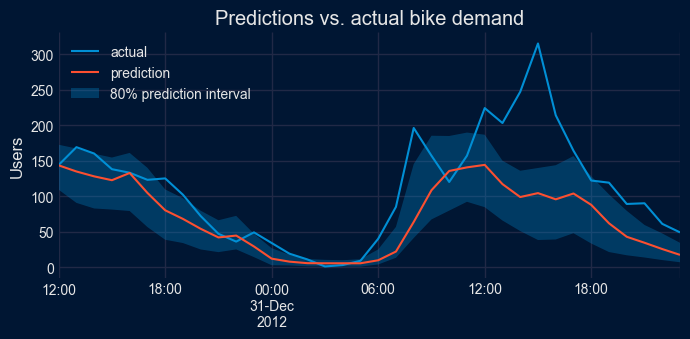

In [17]:
# Plot predictions vs. actual values for the held-out test period
# ==============================================================================
set_dark_theme()
preds = results_eval.predictions
fig, ax = plt.subplots(figsize=(7, 3.5))
data.set_index('date_time').loc[preds.index, 'users'].plot(ax=ax, label='actual')
preds['pred'].plot(ax=ax, label='prediction')
if {'lower_bound', 'upper_bound'}.issubset(preds.columns):
    ax.fill_between(
        preds.index, preds['lower_bound'], preds['upper_bound'],
        alpha=0.3, label='80% prediction interval'
    )
ax.set_title('Predictions vs. actual bike demand')
ax.set_ylabel('Users')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
# Ask the assistant to interpret the forecast results
# ==============================================================================
answer = assistant.ask(
    prompt  = "Explain the results of this forecast, including the metrics and predictions.",
    context = results_eval
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_10410/3255811032.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `context`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `context`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The recursive machine learning forecaster successfully predicted hourly bike users    │
│  for a 36-step horizon, achieving a mean absolute error of 43.081544 and a mean        │
│  absolute scaled error of 0.66908. Because the mean absolute scaled error is below 1,  │
│  this model outperforms the naive baseline. The predictions include an 80 percent      │
│  confidence interval computed via bootstrapping to capture uncertainty.                │
│                                                                                        │
│  Evaluation Metrics                                                                    │
│                                                                                        │
│  The forecaster was evaluated using multiple metrics, which are detailed below:        │
│                                                                                        │
│   • Mean Absolute Error (MAE): 43.081544                                               │
│   • Mean Squared Error (MSE): 3958.072536                                              │
│   • Mean Absolute Scaled Error (MASE): 0.66908                                         │
│   • Mean Absolute Percentage Error (MAPE): 0.516616                                    │
│                                                                                        │
│  The MASE value of 0.66908 indicates that the model is more accurate than a naive      │
│  baseline forecast, as any value below 1 represents an improvement over the baseline.  │
│                                                                                        │
│  Predictions and Interval Summary                                                      │
│                                                                                        │
│  Across the entire 36-step forecast horizon, the point predictions and their           │
│  associated 80 percent bootstrapping intervals are described by the following          │
│  per-column statistics:                                                                │
│                                                                                        │
│   • Predicted Users (pred): The predicted values have a minimum of 5.476745000151495,  │
│     a maximum of 144.05096207975893, and a mean of 70.4999727708395.                   │
│   • Lower Bound (lower_bound): The lower limits of the bootstrapping interval have a   │
│     minimum of 0.8244487408031094, a maximum of 109.07379834084351, and a mean of      │
│     38.64252402650728.                                                                 │
│   • Upper Bound (upper_bound): The upper limits of the bootstrapping interval have a   │
│     minimum of 9.79204556139685, a maximum of 189.54330908626437, and a mean of        │
│     101.73561217137.                                                                   │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### Prediction mode

In prediction mode, the model trains on the entire dataset and forecasts the next `steps` time points. Because the data includes exogenous variables (`holiday`, `weather`, `temp`), their future values must be supplied via the `exog` argument.

In [19]:
# Forecast the next 36 hours using the entire dataset (prediction mode)
# ==============================================================================
# Simulate future values of exogenous variables for the next 36 hours
exog = data[['holiday', 'weather', 'temp']].tail(36).copy()
exog.index = pd.date_range(
    start=pd.to_datetime(data['date_time'].max()) + pd.Timedelta(1, unit='h'),
    periods=36,
    freq='h'
)

results_pred = assistant.forecast(
    data        = data,
    steps       = 36,
    interval    = [0.1, 0.9],
    test_size   = None,        # Use the entire dataset (prediction mode)
    exog        = exog,        # Future values of exogenous variables
    profile     = profile,
    plan        = plan_refined
)

display(results_pred.predictions.head())

,pred,lower_bound,upper_bound
2013-01-01 00:00:00,21.788465,13.456398,32.257294
2013-01-01 01:00:00,11.238868,2.631926,22.624917
2013-01-01 02:00:00,6.435319,1.832387,13.774070
2013-01-01 03:00:00,5.381076,1.065895,11.005487
2013-01-01 04:00:00,5.381076,1.467610,11.282559


In [20]:
# Full results object
# ==============================================================================
results_pred

                          Dataset Profile                          
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                                          ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Format         │ single                                         │
├────────────────┼────────────────────────────────────────────────┤
│ Series         │ 1                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Observations   │ 17544                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Frequency      │ h                                              │
├────────────────┼────────────────────────────────────────────────┤
│ Target         │ users                                          │
├────────────────┼────────────────────────────────────────────────┤
│ Exog columns   │ holiday, weather, temp  (categorical: weather) │
├────────────────┼────────────────────────────────────────────────┤
│ Missing values │ None                                           │
└────────────────┴────────────────────────────────────────────────┘

                                    Recommendation                                     
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property              ┃ Value                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type             │ single_series                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster            │ ForecasterRecursive                                         │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Forecaster candidates │ ForecasterRecursive, ForecasterDirect, ForecasterFoundation │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator             │ LGBMRegressor                                               │
├───────────────────────┼─────────────────────────────────────────────────────────────┤
│ Estimator candidates  │ LGBMRegressor, XGBRegressor, Ridge                          │
└───────────────────────┴─────────────────────────────────────────────────────────────┘

╭───────────────────────────────── Profile Explanation ──────────────────────────────────╮
│                                                                                        │
│  A single-series ML forecaster (ForecasterRecursive) is recommended. Data: 17544       │
│  observations, 'h' frequency. Alternative forecasters: ['ForecasterDirect',            │
│  'ForecasterFoundation']. Estimator: LGBMRegressor. A gradient boosting model is       │
│  preferred for a dataset of this size (17544 observations). Alternative estimators:    │
│  ['XGBRegressor', 'Ridge']. 3 exogenous variables (1 categorical) available as         │
│  predictors.                                                                           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                      Forecast Plan                                       
┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property          ┃ Value                                                              ┃
┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type         │ single_series                                                      │
├───────────────────┼────────────────────────────────────────────────────────────────────┤
│ Forecaster        │ ForecasterRecursive                                             

### Code-only mode

Use `forecast_code()` when you want to preview or export the reproducible script without executing it. This is useful for code review, auditing the generated pipeline, or running the script in a separate environment.

In [21]:
# Generate the reproducible script without executing it
# ==============================================================================
code_result = assistant.forecast_code(
    data        = data,
    steps       = 36,
    test_size   = 36,
    profile     = profile,
    plan        = plan_refined
)
code_result.show_code()

### The ForecastResult object

Both `forecast()` modes return a `ForecastResult`, a lightweight container that bundles everything the assistant used and produced.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Forecasted values. When intervals are requested, the bound columns are included alongside the point predictions. |
| `metrics` | DataFrame or None | Evaluation metrics (`MAE`, `MSE`, `MASE`, `MAPE`), one row per series. `None` in prediction mode. |
| `code` | str | The exact standalone **skforecast** script that produced the forecast, ready to run on its own. |
| `profile` | `ForecastingProfile` | The data profile behind the forecast. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

## Backtesting

The backtesting branch uses the same `profile` and `plan` as the forecast branch but evaluates the model's historical performance through time series cross-validation. The key decision is how to configure the `TimeSeriesFold` object, which controls exactly how the historical data is partitioned into successive training and test windows.

skforecast-ai provides three distinct ways to define this validation strategy:

1. **Explicit instantiation (recommended)**: manually construct a `TimeSeriesFold` and pass it directly to `backtest()`. Use this when you already know your exact operational constraints.

2. **Deterministic `create_cv()`**: allow the assistant to derive a sensible `TimeSeriesFold` from the profile and plan using rule-based defaults. You can override individual parameters explicitly.

3. **LLM `create_cv()` (with a prompt)**: describe your deployment use case in natural language. The LLM translates your description into a fully-configured `TimeSeriesFold`, accompanied by an explanation you can audit.

### Define the backtesting strategy

#### Manual TimeSeriesFold

In [22]:
# Create your own TimeSeriesFold object
# ==============================================================================
end_train = '2012-08-31 23:59:00'
cv = TimeSeriesFold(
    steps              = 36,
    initial_train_size = end_train,
    refit              = False,
    verbose            = False
)
cv

TimeSeriesFold(
    initial_train_size    = 2012-08-31 23:59:00,
    steps                 = 36,
    fold_stride           = 36,
    window_size           = None,
    differentiation       = None,
    refit                 = False,
    fixed_train_size      = True,
    gap                   = 0,
    skip_folds            = None,
    allow_incomplete_fold = True,
    return_all_indexes    = False,
    verbose               = False,
)

#### Deterministic create_cv()

In [23]:
# Let the assistant derive a TimeSeriesFold with rule-based defaults
# ==============================================================================
cv_det = assistant.create_cv(
    profile            = profile,
    plan               = plan_refined,
    initial_train_size = end_train,
    refit              = False,
)

cv_det

╭───────────────────────────── Cross-Validation Explanation ─────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, expanding window, no refit, 36-step       │
│  horizon, 82 folds.                                                                    │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
        Cross-Validation Configuration         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter             ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps                 │                  36 │
├───────────────────────┼─────────────────────┤
│ initial_train_size    │ 2012-08-31 23:59:00 │
├───────────────────────┼─────────────────────┤
│ refit                 │               False │
├───────────────────────┼─────────────────────┤
│ fixed_train_size      │               False │
├───────────────────────┼─────────────────────┤
│ gap                   │                   0 │
├───────────────────────┼─────────────────────┤
│ fold_stride           │                  36 │
├───────────────────────┼─────────────────────┤
│ skip_folds            │                None │
├───────────────────────┼─────────────────────┤
│ allow_incomplete_fold │                True │
├───────────────────────┼─────────────────────┤
│ differentiation       │                None │
├───────────────────────┼─────────────────────┤
│ n_folds               │                  82 │
└───────────────────────┴─────────────────────┘
───────────────────────────────────── Generated code ─────────────────────────────────────
from skforecast.model_selection import TimeSeriesFold                                     
                                                                                          
# Time series cross-validation configuration                                              
cv = TimeSeriesFold(                                                                      
    steps              = 36,                                                              
    initial_train_size = '2012-08-31 23:59:00',                                           
    refit              = False,                                                           
)                                                                                         
                                                                                          

#### LLM create_cv() with a natural-language prompt

Rather than manually configuring `TimeSeriesFold` parameters, you can describe your backtesting strategy in natural language and let the assistant translate it into a rigorous cross-validation schema.

In [24]:
# Let the assistant create the TimeSeriesFold from a natural-language prompt
# ==============================================================================
prompt = (
    "I forecast bike demand 36 hours ahead. "
    "The model should be trained once on all data up to the end of August 2012, 23:59. "
    "Do not refit the model as the window rolls forward."
)
cv_llm = assistant.create_cv(
    profile = profile,
    plan    = plan_refined,
    prompt  = prompt
)

In [25]:
# Cross-validation strategy derived from the prompt
# ==============================================================================
cv_llm

╭───────────────────────────── Cross-Validation Explanation ─────────────────────────────╮
│                                                                                        │
│  The user specified that the model should be trained once on all data up to the end    │
│  of August 2012, which corresponds to the ISO datetime '2012-08-31 23:00:00' (since    │
│  the frequency is hourly and the last observation of August is at 23:00:00). To avoid  │
│  retraining the model as evaluation progresses, we set refit=False. This leaves        │
│  approximately 4 months of hourly data (September to December 2012, ~2,928             │
│  observations) for backtesting, which is more than enough to satisfy the requirement   │
│  of at least 2 folds of 36 steps. Initial training up to 2012-08-31 23:00:00,          │
│  expanding window, no refit, 36-step horizon, 82 folds.                                │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
        Cross-Validation Configuration         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter             ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps                 │                  36 │
├───────────────────────┼─────────────────────┤
│ initial_train_size    │ 2012-08-31 23:00:00 │
├───────────────────────┼─────────────────────┤
│ refit                 │               False │
├───────────────────────┼─────────────────────┤
│ fixed_train_size      │               False │
├───────────────────────┼─────────────────────┤
│ gap                   │                   0 │
├───────────────────────┼─────────────────────┤
│ fold_stride           │                  36 │
├───────────────────────┼─────────────────────┤
│ skip_folds            │                None │
├───────────────────────┼─────────────────────┤
│ allow_incomplete_fold │                True │
├───────────────────────┼─────────────────────┤
│ differentiation       │                None │
├───────────────────────┼─────────────────────┤
│ n_folds               │                  82 │
└───────────────────────┴─────────────────────┘
───────────────────────────────────── Generated code ─────────────────────────────────────
from skforecast.model_selection import TimeSeriesFold                                     
                                                                                          
# Time series cross-validation configuration                                              
cv = TimeSeriesFold(                                                                      
    steps              = 36,                                                              
    initial_train_size = '2012-08-31 23:00:00',                                           
    refit              = False,                                                           
)                                                                                         
                                                                                          

In [26]:
# LLM reasoning behind the TimeSeriesFold configuration
# ==============================================================================
print(textwrap.fill(cv_llm.explanation, width=88))

The user specified that the model should be trained once on all data up to the end of
August 2012, which corresponds to the ISO datetime '2012-08-31 23:00:00' (since the
frequency is hourly and the last observation of August is at 23:00:00). To avoid
retraining the model as evaluation progresses, we set `refit=False`. This leaves
approximately 4 months of hourly data (September to December 2012, ~2,928 observations)
for backtesting, which is more than enough to satisfy the requirement of at least 2
folds of 36 steps. Initial training up to 2012-08-31 23:00:00, expanding window, no
refit, 36-step horizon, 82 folds.


Since the `prompt` correctly describes the intended use case, the `cv_llm` object returned by `create_cv()` is equivalent to the one we built manually (the same 82 folds; the timestamp is aligned to the hourly frequency). However, it was derived entirely from a natural-language description. The returned `CVResult` carries the splitter as `cv_llm.cv` and, as `cv_llm.explanation`, a description of the choices the assistant made, allowing you to verify that the resulting `TimeSeriesFold` matches your intended strategy before executing the backtest.

### Run the backtest

In [27]:
# Run backtesting, reusing the pre-computed profile and plan
# ==============================================================================
results_backtest = assistant.backtest(
    data        = data,
    cv          = cv,           # TimeSeriesFold, or a CVResult from create_cv()
    interval    = [0.1, 0.9],   # 80% prediction interval
    profile     = profile,      # Reuse the pre-computed profile
    plan        = plan_refined  # Reuse the refined plan
)

results_backtest.show_explanation()
display(results_backtest.metrics)
display(results_backtest.predictions.head())

  0%|          | 0/82 [00:00<?, ?it/s]

╭───────────────────────────────── Backtest Explanation ─────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results: mean_absolute_error: 49.2407, mean_squared_error: 6552.0857,       │
│  mean_absolute_scaled_error: 0.8031, mean_absolute_percentage_error: 0.5362.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,49.24074,6552.085694,0.80309,0.536218


,fold,pred,lower_bound,upper_bound
2012-09-01 00:00:00,0,129.711772,101.239276,152.968417
2012-09-01 01:00:00,0,108.817323,79.935373,145.297216
2012-09-01 02:00:00,0,68.007618,44.461607,100.676964
2012-09-01 03:00:00,0,37.932989,18.533129,65.785327
2012-09-01 04:00:00,0,16.230278,5.940862,34.380624


In [28]:
# Plot prediction intervals vs real value
# ==============================================================================
predictions = results_backtest.predictions
data_test = data.set_index("date_time").loc[predictions.index, :]

fig = go.Figure([
    go.Scatter(name='Prediction', x=predictions.index, y=predictions['pred'], mode='lines'),
    go.Scatter(
        name='Real value', x=data_test.index, y=data_test['users'], mode='lines',
    ),
    go.Scatter(
        name='Upper Bound', x=predictions.index, y=predictions['upper_bound'], mode='lines',
        marker=dict(color="#444"), line=dict(width=0), showlegend=False
    ),
    go.Scatter(
        name='Lower Bound', x=predictions.index, y=predictions['lower_bound'], marker=dict(color="#444"),
        line=dict(width=0), mode='lines', fillcolor='rgba(68, 68, 68, 0.3)', fill='tonexty', showlegend=False
    )
])
fig.update_layout(
    title="Real value vs predicted in test data",
    xaxis_title="Date time",
    yaxis_title="users",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    hovermode="x",
    legend=dict(orientation="h", yanchor="top", y=1.1, xanchor="left", x=0.001),
    # Initial zoom on x axis betwee 1 oct to 10 oct
    xaxis=dict(range=['2012-10-01', '2012-10-10'])
)
fig.show()

In [29]:
# Ask the assistant to interpret the backtesting results
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "Explain the results of this backtesting, including the strategy, metrics, "
        "and predictions. Is the model good enough to deploy?"
    ),
    context = results_backtest
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_10410/2899763076.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `context`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `context`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The backtesting evaluated a recursive single-series model using an LGBMRegressor to   │
│  forecast hourly users over a 36-step horizon. The model achieved a Mean Absolute      │
│  Error of 49.2407 and a Mean Absolute Scaled Error of 0.8031. Because the Mean         │
│  Absolute Scaled Error is below the baseline threshold of 1.0, the model successfully  │
│  outperforms the naive baseline and is a viable candidate for deployment.              │
│                                                                                        │
│  Backtesting Strategy                                                                  │
│                                                                                        │
│   • Forecaster: ForecasterRecursive with an LGBMRegressor estimator, designed to       │
│     handle the 17544 hourly observations.                                              │
│   • Inputs: Predictors include lags [1, 2, 3, 4, 23, 24, 25, 167, 168, 169], rolling   │
│     window features (window sizes 4, 24, and 168), and calendar features (hour,        │
│     day_of_week, weekend, and month).                                                  │
│   • Exogenous Variables: Holiday, weather, and temp were included, with weather        │
│     automatically treated as a categorical variable.                                   │
│   • Validation: The cross-validation setup used an initial training size up to         │
│     2012-08-31 23:59:00, a fixed window size, no retraining (refit: False), a gap of   │
│     0, and a fold stride of 36. This simulated a production environment over 82        │
│     folds.                                                                             │
│                                                                                        │
│  Evaluation Metrics                                                                    │
│                                                                                        │
│   • Mean Absolute Error: 49.2407                                                       │
│   • Mean Squared Error: 6552.0857                                                      │
│   • Mean Absolute Scaled Error: 0.8031                                                 │
│   • Mean Absolute Percentage Error: 0.5362                                             │
│                                                                                        │
│  The Mean Absolute Scaled Error (MASE) of 0.8031 is below the standard baseline        │
│  threshold of 1.0. This indicates that the forecaster makes better predictions than a  │
│  naive seasonal baseline model. Based on this comparison, the model is qualified for   │
│  deployment.                                                                           │
│                                                                                        │
│  Prediction and Interval Analysis                                                      │
│                                                                                        │
│  A total of 2928 predictions were generated, accompanied by an 80% prediction          │
│  interval (between the 0.1 and 0.9 quantiles) calculated using bootstrapping.          │
│                                                                                        │
│  The complete set of predictions shows the following metrics:                          │
│                                                                                        │
│   • Predictions (pred): Minimum of 3.2696726423777087, maximum of 877.9626326839831,   │
│     and mean of 228.85831049240878.                                                    │
│   • Lower Bound: Minimum of -1.1038444989851766, maximum of 813.6162935852826, and   

### Code-only mode

Use `backtest_code()` to generate the reproducible backtesting script without executing it.

In [30]:
# Generate the reproducible backtest script without executing it
# ==============================================================================
code_bt = assistant.backtest_code(
    data        = data,
    cv          = cv,
    profile     = profile,
    plan        = plan_refined
)
code_bt.show_code()

### The BacktestResult object

The `backtest()` method returns a `BacktestResult`, a lightweight container that bundles all the backtesting artifacts.

| Attribute | Type | Description |
|---|---|---|
| `predictions` | DataFrame | Full out-of-sample backtest predictions across all folds. |
| `metrics` | DataFrame | Backtesting metrics (`MAE`, `MSE`, `MASE`, `MAPE`), one row per series, computed across all folds. |
| `cv_config` | dict | Resolved `TimeSeriesFold` parameters for full traceability of the validation strategy. |
| `code` | str | The exact standalone **skforecast** script that reproduces the backtesting workflow. |
| `explanation` | str | Human-readable summary of the backtesting configuration and results. |
| `profile` | `ForecastingProfile` | The data profile behind the backtest. |
| `plan` | `ForecastPlan` | The detailed configuration that was executed. |

In [31]:
# Full results object
# ==============================================================================
results_backtest

╭───────────────────────────────── Backtest Explanation ─────────────────────────────────╮
│                                                                                        │
│  Initial training up to 2012-08-31 23:59:00, fixed window, no refit, 36-step horizon,  │
│  82 folds. Results: mean_absolute_error: 49.2407, mean_squared_error: 6552.0857,       │
│  mean_absolute_scaled_error: 0.8031, mean_absolute_percentage_error: 0.5362.           │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
        Cross-Validation Configuration         
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Parameter             ┃               Value ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ steps                 │                  36 │
├───────────────────────┼─────────────────────┤
│ initial_train_size    │ 2012-08-31 23:59:00 │
├───────────────────────┼─────────────────────┤
│ refit                 │               False │
├───────────────────────┼─────────────────────┤
│ fixed_train_size      │                True │
├───────────────────────┼─────────────────────┤
│ gap                   │                   0 │
├───────────────────────┼─────────────────────┤
│ fold_stride           │                  36 │
├───────────────────────┼─────────────────────┤
│ skip_folds            │                None │
├───────────────────────┼─────────────────────┤
│ allow_incomplete_fold │                True │
├───────────────────────┼─────────────────────┤
│ differentiation       │                None │
├───────────────────────┼─────────────────────┤
│ n_folds               │                  82 │
└───────────────────────┴─────────────────────┘
                                     Backtest Metrics                                     
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ mean_absolute_error ┃ mean_squared_error ┃ mean_absolute_scale… ┃ mean_absolute_perce… ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│             49.2407 │          6552.0857 │               0.8031 │               0.5362 │
└─────────────────────┴────────────────────┴──────────────────────┴──────────────────────┘
                    Backtest Predictions (2928 rows)                    
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Index               ┃    fold ┃     pred ┃ lower_bound ┃ upper_bound ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ 2012-09-01 00:00:00 │  0.0000 │ 129.7118 │    101.2393 │    152.9684 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 01:00:00 │  0.0000 │ 108.8173 │     79.9354 │    145.2972 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 02:00:00 │  0.0000 │  68.0076 │     44.4616 │    100.6770 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 03:00:00 │  0.0000 │  37.9330 │     18.5331 │     65.7853 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-09-01 04:00:00 │  0.0000 │  16.2303 │      5.9409 │     34.3806 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ ...                 │     ... │      ... │         ... │         ... │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 19:00:00 │ 81.0000 │  55.8594 │     27.0487 │     96.7762 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 20:00:00 │ 81.0000 │  38.3103 │     16.4275 │     76.1822 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 21:00:00 │ 81.0000 │  28.1299 │     11.7702 │     59.2780 │
├─────────────────────┼─────────┼──────────┼─────────────┼─────────────┤
│ 2012-12-31 22:00:00 │ 81.0000 │  19.6876 │      7.7415 │ 

## Comparing forecaster configurations

Choosing a forecasting model should not rely on intuition alone. Two configurations that look equally reasonable can perform very differently once evaluated on real temporal data. The most reliable approach is to test every candidate under **identical conditions** and compare their metrics.

The `compare()` method does exactly that. It receives a list of candidate configurations, backtests each one using the same `TimeSeriesFold` strategy, and returns a leaderboard ranked by the selected metric.

In the step-by-step path, the key argument is `profile`. Passing the profile computed at the beginning of this tutorial skips profiling entirely and guarantees that every candidate is evaluated against the **same** data profile. Note that `compare()` does not accept a `plan`: each candidate derives its own plan from the shared profile, which is precisely what makes the candidates differ.

Candidates can be provided in two ways:

+ **Automatic candidates (`candidates=None`)**: the assistant builds the comparison set from the `profile.forecaster_candidates` that belong to the same family as the recommended forecaster, so every row is scored on the same thing. For multi-series data, where a multi-series forecaster is never ranked against a multivariate one, the candidates are the estimators of the recommended forecaster instead. This is useful when exploring a new dataset without a predefined shortlist.

+ **Explicit candidates (recommended)**: pass a list of `(name, config)` tuples, where `name` labels the row in the leaderboard and `config` holds the same override keys understood by `plan()`: `'forecaster'`, `'estimator'`, `'estimator_kwargs'`, `'lags'` and `'window_features'`. This provides full control and makes the resulting table easier to interpret.

A failed candidate does not stop the comparison. Instead, a `CandidateFailedWarning` is issued, the row records the error and is placed last.

<div role="note"
    style="background: rgba(0,191,191,.08); border-left: 6px solid #00bfa5;
        border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#00bfa5;
        margin:0 0 6px 0; font-weight:600;">
<span style="margin-right:6px; font-size:18px;">💡</span>
<strong style="margin-right:6px; font-size:18px;">Tip</strong>
</p>

<p>

All candidates use the same cross-validation strategy, ensuring a fair comparison. However, the results are only meaningful if the <code>cv</code> setup reflects the real use case where the model will be deployed. For example, if the production system retrains weekly, the backtest should also refit weekly. If the model is expected to forecast 24 hours ahead, the backtest should use a 24-hour horizon.

The evaluation window must also be representative. A period that is too short or dominated by unusual events (holidays, outages, or exceptional peaks) may favor a candidate that performs poorly over time. Define the validation setup carefully before comparing models so the final ranking is reliable.

</p>

</div>

### Automatic candidates

In [32]:
# Compare the forecaster candidates suggested by the profile
# ==============================================================================
results_compare = assistant.compare(
    data        = data,
    cv          = cv,       # Same TimeSeriesFold used in the backtest above
    candidates  = None,     # Candidates suggested by the assistant 
    profile     = profile   # Reuse the pre-computed profile
)

Comparing forecasters:   0%|          | 0/3 [00:00<?, ?it/s]

In [33]:
# Ranked leaderboard
# ==============================================================================
results_compare.results

,rank,name,forecaster,estimator,mean_absolute_error,mean_squared_error,mean_absolute_scaled_error,mean_absolute_percentage_error
0,1,ForecasterFoundation,ForecasterFoundation,Chronos-2,38.436160,4231.326474,0.597467,0.611349
1,2,ForecasterRecursive,ForecasterRecursive,LGBMRegressor,46.312218,5495.881638,0.749598,0.472735
2,3,ForecasterDirect,ForecasterDirect,LGBMRegressor,49.298312,5936.622526,0.797930,0.499413


In [34]:
# Deterministic summary of the comparison
# ==============================================================================
results_compare.show_explanation()

╭──────────────────────────────── Comparison Explanation ────────────────────────────────╮
│                                                                                        │
│  Compared 3 configurations, ranked ascending by mean_absolute_error. Shared            │
│  cross-validation strategy: Initial training up to 2012-08-31 23:59:00, fixed window,  │
│  no refit, 36-step horizon, 82 folds. Best: 'ForecasterFoundation'                     │
│  (ForecasterFoundation / Chronos-2) = 38.4362, 17.0% ahead of 'ForecasterRecursive'    │
│  (46.3122).                                                                            │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### Explicit candidates

In practice, you will often already have a shortlist in mind: a fast baseline, a gradient boosting model, or a variant with a richer feature set. Passing explicit `(name, config)` tuples keeps the comparison focused and makes the resulting leaderboard easy to understand at a glance.

The `config` dictionary accepts the same overrides as `plan()`. Any omitted option falls back to the deterministic recommendation derived from the shared profile, so candidates can remain concise. For example, `{'forecaster': 'ForecasterDirect'}` changes only the forecaster while keeping the recommended estimator, lags, and features.

<div role="alert" style="background: rgba(255,145,0,.08); border-left: 6px solid #ff9100; border-radius: 6px; padding: 10px 12px; margin: 1em 0;">

<p style="display:flex; align-items:center; font-size:1rem; color:#ff9100; margin:0 0 6px 0; font-weight:600;">
    <span style="margin-right:6px; font-size:18px;">⚠️</span>
    <strong style="margin-right:6px; font-size:18px;">Computational cost</strong>
</p>

<p>
Each candidate is backtested independently across all folds, so runtime increases with both the number and complexity of the configurations. Comparing four candidates will take roughly four times as long as running one backtest.

Start with a small set of clearly different options, review the results, and refine from there. Testing many near-identical variants is costly and rarely useful.
</p>

</div>

In [35]:
# Compare an explicit shortlist of configurations
# ==============================================================================
candidates = [
    (
        "ridge_baseline",
        {
            "forecaster": "ForecasterRecursive",
            "estimator" : "Ridge",
            "lags"      : 24,
        }
    ),
    (
        "lgbm_daily_lags",
        {
            "forecaster": "ForecasterRecursive",
            "estimator" : "LGBMRegressor",
            "lags"      : 24,
        }
    ),
    (
        "refined_plan",
        {
            "forecaster"      : plan_refined.forecaster,
            "estimator"       : plan_refined.estimator,
            "lags"            : plan_refined.forecaster_kwargs.get("lags"),
            "window_features" : plan_refined.forecaster_kwargs.get("window_features"),
        }
    ),
    (
        "lgbm_direct",
        {
            "forecaster": "ForecasterDirect",
            "estimator" : "LGBMRegressor",
            "lags"      : 24,
        }
    ),
    (
        "foundation_model",
        {
            "forecaster": "ForecasterFoundation"
        }
    ),
]

results_compare = assistant.compare(
    data        = data,
    cv          = cv,
    candidates  = candidates,  # Specific candidates to compare
    metric      = ['mean_absolute_error', 'mean_absolute_scaled_error'],
    profile     = profile
)

Comparing forecasters:   0%|          | 0/5 [00:00<?, ?it/s]

The `refined_plan` candidate reuses the forecaster, estimator, lags and window features of the plan produced by `refine_plan()`. This is the recommended way to validate a refined plan: the leaderboard shows whether the extra domain knowledge actually improves the metrics compared to the deterministic baselines.

When several metrics are requested, all of them are shown as columns but only the **first** one drives the ranking.

In [36]:
# Ranked leaderboard, sorted by the first metric requested
# ==============================================================================
results_compare.results

,rank,name,forecaster,estimator,mean_absolute_error,mean_absolute_scaled_error
0,1,foundation_model,ForecasterFoundation,Chronos-2,38.436160,0.597467
1,2,refined_plan,ForecasterRecursive,LGBMRegressor,49.240740,0.803090
2,3,lgbm_direct,ForecasterDirect,LGBMRegressor,50.224908,0.819189
3,4,lgbm_daily_lags,ForecasterRecursive,LGBMRegressor,55.517689,0.905517
4,5,ridge_baseline,ForecasterRecursive,Ridge,93.145620,1.519244


### Inspect individual candidates

Because every candidate is a full `BacktestResult`, the details of any individual configuration remain available, including its metrics, its predictions and the standalone script that generated them.

In [37]:
# Inspect a specific candidate
# ==============================================================================
candidate = results_compare.candidates['foundation_model']

display(candidate.metrics)
display(candidate.predictions.head())
candidate.show_code()

,mean_absolute_error,mean_absolute_scaled_error
0,38.43616,0.597467


,level,fold,pred
2012-09-01 00:00:00,users,0,148.059464
2012-09-01 01:00:00,users,0,102.715004
2012-09-01 02:00:00,users,0,66.084427
2012-09-01 03:00:00,users,0,40.878662
2012-09-01 04:00:00,users,0,29.577866


### Reuse the winning configuration

The most useful result of a comparison is often not the leaderboard, but `best_candidate`. It is a complete `BacktestResult` carrying both the winning `profile` and `plan`, so it can be fed back into the step-by-step workflow without manually rebuilding the configuration.

In [38]:
# Winning configuration
# ==============================================================================
print(f"Best candidate: {results_compare.best_name}")
results_compare.best_candidate.plan

Best candidate: foundation_model


              Forecast Plan              
┏━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Property       ┃ Value                ┃
┡━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ Task type      │ foundation           │
├────────────────┼──────────────────────┤
│ Forecaster     │ ForecasterFoundation │
├────────────────┼──────────────────────┤
│ Estimator      │ Chronos-2            │
├────────────────┼──────────────────────┤
│ Steps          │ 36                   │
├────────────────┼──────────────────────┤
│ Frequency      │ h                    │
├────────────────┼──────────────────────┤
│ Use exog       │ True                 │
├────────────────┼──────────────────────┤
│ Interval       │ None                 │
├────────────────┼──────────────────────┤
│ Primary metric │ mean_absolute_error  │
├────────────────┼──────────────────────┤
│ Preprocessing  │ 1 step               │
└────────────────┴──────────────────────┘

                                   Preprocessing Steps                                    
┏━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Step                    ┃ Reason                                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ handle_categorical_exog │ Categorical exogenous variables detected: ['weather'].       │
│                         │ Chronos-2 consumes categorical covariates natively, so no    │
│                         │ encoding is needed.                                          │
└─────────────────────────┴──────────────────────────────────────────────────────────────┘

╭─────────────────────────────────── Plan Explanation ───────────────────────────────────╮
│                                                                                        │
│  Plan: ForecasterFoundation + Chronos-2. No lag or window features: the foundation     │
│  model forecasts directly from the raw context window. Exogenous variables included.   │
│  MAE is interpretable, robust to outliers, and works at any scale.                     │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

In [39]:
# Produce the final forecast with the winning configuration
# ==============================================================================
results_pred_best = assistant.forecast(
    data        = data,
    steps       = 36,
    interval    = [0.1, 0.9],
    test_size   = None,                                # Prediction mode
    exog        = exog,                                # Future values of exogenous variables
    profile     = results_compare.profile,             # Shared profile
    plan        = results_compare.best_candidate.plan  # Winning plan
)

results_pred_best.show_code()

### Explain mode (comparison)

Like any other result, a `ComparisonResult` can be passed to `ask()` as `context` to explain why the ranking looks the way it does. However, the LLM cannot change the outcome: all metrics and rankings are computed deterministically before it sees the result.

In [40]:
# Ask the assistant to interpret the comparison
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "Explain the comparison results. Is the margin between the top candidates "
        "meaningful, or are they practically equivalent?"
    ),
    context = results_compare
)
answer.show_explanation()

/var/folders/wt/8tvn563d5v55nspfbydgqb9r0000gp/T/ipykernel_10410/2209842622.py:3: DataSentToLLMWarning: `send_data_to_llm=False` does not apply to `context`: the predicted values it carries are sent to the LLM, because a question about a result cannot be answered from summary statistics alone. Your input data is not sent: a result holds only the model's output, never the data it was fitted on. To keep predictions local, ask without `context`.
  answer = assistant.ask(


╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  The comparison results show that the foundation model configuration achieved the      │
│  lowest mean absolute error of 38.436160, followed by the refined plan configuration   │
│  with an error of 49.240740. The margin between these top two candidates is            │
│  meaningful, with the foundation model performing 21.9% ahead of the refined plan.     │
│  Both configurations successfully beat the naive baseline, as indicated by their mean  │
│  absolute scaled error values falling below 1.                                         │
│                                                                                        │
│  Leaderboard Summary                                                                   │
│                                                                                        │
│  The 5 evaluated candidates were ranked deterministically by mean absolute error in    │
│  ascending order:                                                                      │
│                                                                                        │
│   • Rank 1: foundation_model (ForecasterFoundation using Chronos-2) achieved a mean    │
│     absolute error of 38.436160 and a mean absolute scaled error of 0.597467.          │
│   • Rank 2: refined_plan (ForecasterRecursive using LGBMRegressor) achieved a mean     │
│     absolute error of 49.240740 and a mean absolute scaled error of 0.803090.          │
│   • Rank 3: lgbm_direct (ForecasterDirect using LGBMRegressor) achieved a mean         │
│     absolute error of 50.224908 and a mean absolute scaled error of 0.819189.          │
│   • Rank 4: lgbm_daily_lags (ForecasterRecursive using LGBMRegressor) achieved a mean  │
│     absolute error of 55.517689 and a mean absolute scaled error of 0.905517.          │
│   • Rank 5: ridge_baseline (ForecasterRecursive using Ridge) achieved a mean absolute  │
│     error of 93.145620 and a mean absolute scaled error of 1.519244.                   │
│                                                                                        │
│  Margin and Baseline Comparison                                                        │
│                                                                                        │
│  The foundation model is the clear winner of the evaluation. With a mean absolute      │
│  error of 38.4362, it is 21.9% ahead of the second-best configuration, the refined     │
│  plan, which finished with a mean absolute error of 49.2407.                           │
│                                                                                        │
│  When evaluating performance against the baseline, a mean absolute scaled error below  │
│  1 indicates that the configuration beat the naive baseline, whereas a value above 1   │
│  indicates that it did not. Based on this criteria:                                    │
│                                                                                        │
│   • The foundation_model, refined_plan, lgbm_direct, and lgbm_daily_lags               │
│     configurations all achieved a mean absolute scaled error below 1, meaning they     │
│     successfully beat the naive baseline.                                              │
│   • The ridge_baseline configuration finished with a mean absolute scaled error of     │
│     1.519244, meaning it did not beat the naive baseline.                              │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯

### The ComparisonResult object

The `compare()` method returns a `ComparisonResult`, which groups the shared setup, the ranked leaderboard, and the individual backtests in a single object.

| Attribute | Type | Description |
|---|---|---|
| `results` | DataFrame | Ranked leaderboard, one row per candidate, sorted best to worst. Columns: `rank`, `name`, `forecaster`, `estimator`, the metric columns, and `error` when at least one candidate failed. |
| `candidates` | dict | Mapping of candidate name to the full `BacktestResult` object. |
| `failures` | dict | Mapping of candidate name to a `CandidateFailure` describing why it failed. Empty when every candidate succeeds. |
| `ranking_metric` | str | Name of the metric used to sort `results`. |
| `cv_config` | dict | Resolved `TimeSeriesFold` parameters plus the resulting `n_folds`, applied identically to every candidate. |
| `profile` | `ForecastingProfile` | The shared data profile behind every candidate. |
| `explanation` | str | Deterministic, human-readable summary of the comparison. |
| `best_name` | str | Name of the top-ranked candidate. |
| `best_candidate` | `BacktestResult` | Top-ranked candidate as a complete `BacktestResult`. |

In [41]:
# Full results object
# ==============================================================================
results_compare

╭──────────────────────────────── Comparison Explanation ────────────────────────────────╮
│                                                                                        │
│  Compared 5 configurations, ranked ascending by mean_absolute_error. Shared            │
│  cross-validation strategy: Initial training up to 2012-08-31 23:59:00, fixed window,  │
│  no refit, 36-step horizon, 82 folds. Best: 'foundation_model' (ForecasterFoundation   │
│  / Chronos-2) = 38.4362, 21.9% ahead of 'refined_plan' (49.2407).                      │
│                                                                                        │
╰────────────────────────────────────────────────────────────────────────────────────────╯
                                    Comparison Results                                    
┏━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Index ┃ rank ┃         name ┃   forecaster ┃    estimator ┃ mean_absol… ┃ mean_absolu… ┃
┡━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ 0     │    1 │ foundation_… │ ForecasterF… │    Chronos-2 │     38.4362 │       0.5975 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 1     │    2 │ refined_plan │ ForecasterR… │ LGBMRegress… │     49.2407 │       0.8031 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 2     │    3 │  lgbm_direct │ ForecasterD… │ LGBMRegress… │     50.2249 │       0.8192 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 3     │    4 │ lgbm_daily_… │ ForecasterR… │ LGBMRegress… │     55.5177 │       0.9055 │
├───────┼──────┼──────────────┼──────────────┼──────────────┼─────────────┼──────────────┤
│ 4     │    5 │ ridge_basel… │ ForecasterR… │        Ridge │     93.1456 │       1.5192 │
└───────┴──────┴──────────────┴──────────────┴──────────────┴─────────────┴──────────────┘

## Reproducible code

Every forecast or backtest workflow exposes the standalone skforecast script used to produce its results. This script is strictly deterministic, ensuring identical outputs for a given set of inputs and configurations. You can access the code at any time via the `show_code()` method.

## Free-form Q&A

The `ask()` method is not limited to interpreting workflow objects. Without any `context` attached, it works as a general forecasting knowledge assistant, useful for clarifying methodology, choosing between approaches, or understanding metric trade-offs.

Without a context there is no task type to route on, so only the general `choosing-a-forecaster` skill is sent unless the question mentions a topic (intervals, backtesting, metrics, ...) that pulls in a specific one. Pass `skills=` to pick them yourself; the names sent are recorded in `answer.skills`. See [Skills for the LLM](./skills.html).

In [42]:
# Ask a general forecasting question (no data or result required)
# ==============================================================================
answer = assistant.ask(
    prompt = (
        "For hourly demand with strong daily and weekly seasonality, when should "
        "I prefer a direct forecasting strategy over a recursive one?"
    )
)
answer.show_explanation()

╭────────────────────────────────── Assistant Response ──────────────────────────────────╮
│                                                                                        │
│  For hourly demand with strong daily and weekly seasonality, you should prefer a       │
│  direct forecasting strategy (ForecasterDirect) when the predictive relationship       │
│  changes significantly across the forecast horizon or when error propagation from      │
│  recursive predictions degrades long-term accuracy. Although it is more                │
│  computationally intensive because it trains a separate model for each step, a direct  │
│  strategy prevents early forecasting errors from compounding over 24-hour or 168-hour  │
│  horizons.                                                                             │
│                                                                                        │
│  Here are the key scenarios and reasons to choose a direct strategy for hourly         │
│  seasonal demand:                                                                      │
│                                                                                        │
│  Preventing Error Propagation                                                          │
│                                                                                        │
│   • In a recursive strategy (ForecasterRecursive), predictions for the next hour are   │
│     fed back into the model to predict subsequent hours. Over longer horizons, such    │
│     as 24 hours (daily cycle) or 168 hours (weekly cycle), small errors in early       │
│     steps compound and can degrade accuracy.                                           │
│   • A direct strategy (ForecasterDirect) trains independent models for each step in    │
│     the horizon, meaning a 24-hour-ahead forecast does not rely on potentially         │
│     inaccurate predictions from hours 1 through 23.                                    │
│                                                                                        │
│  Horizon-Dependent Relationships                                                       │
│                                                                                        │
│   • The drivers of hourly demand can vary drastically depending on the target step.    │
│     For example, predicting demand 1 hour from now depends heavily on immediate        │
│     autocorrelation (the last few hours), whereas predicting demand 24 hours from now  │
│     is heavily driven by the daily cycle.                                              │
│   • Direct forecasting allows the training process to optimize a separate model        │
│     specifically for each step, capturing these horizon-specific patterns more         │
│     effectively than a single recursive model.                                         │
│                                                                                        │
│  Implementation Trade-offs to Consider                                                 │
│                                                                                        │
│   • Training speed: Direct forecasting requires training N models (where N is the      │
│     number of steps in your horizon), making it slower than recursive forecasting.     │
│     However, this process can be parallelized using the n_jobs parameter in            │
│     ForecasterDirect.                                                                  │
│   • Horizon flexibility: Unlike recursive models, which can predict any arbitrary      │
│     number of steps at prediction time, direct models require you to predefine the     │
│     maximum forecast horizon (steps) during initialization.                            │
│                                                                                        │
╰──────────────────────────────────────────────────────────────────────────────────────

## Summary

This tutorial covered the **step-by-step path** of `skforecast-ai`. Here is a recap of what each stage does and when to use it:

| Step | Method | When to use |
|---|---|---|
| 1. Profile | `profile()` | Always: produces the `ForecastingProfile` required by all downstream methods. |
| 2. Plan | `plan()` | Always: converts the profile into an executable configuration. |
| 3. Refine plan | `refine_plan()` | Optional: use when you want to override specific decisions (deterministic) or inject domain knowledge (LLM). Always evaluate the result. |
| 4a. Forecast | `forecast()` | When you want future predictions or a held-out evaluation in a single execution. |
| 4a. Code only | `forecast_code()` | When you want to preview or export the script without running it. |
| 4b. CV strategy | `create_cv()` | When you want the assistant to derive or translate a `TimeSeriesFold` for you. |
| 4b. Backtest | `backtest()` | When you want to evaluate the model over multiple historical folds. |
| 4b. Code only | `backtest_code()` | When you want to preview or export the backtesting script without running it. |
| 4c. Compare | `compare()` | When you want to rank several configurations under an identical cross-validation strategy and reuse the winner. |
| Any time | `ask()` | When you want an LLM explanation of any intermediate object or result, or a general forecasting Q&A. |

The key advantage of this path is that the `profile` and `plan` are built **once** and reused across both the forecast and backtest branches. This avoids redundant profiling and ensures that both branches use the same modeling configuration. The same profile can also be handed to `compare()`, so every candidate is ranked against the very same data profile.

For a faster alternative that runs the entire pipeline in a single call, see the [fast-path tutorial](./agentic-forecasting.html). For a comprehensive overview of backtesting mechanics, see the [skforecast backtesting user guide](https://skforecast.org/latest/user_guides/backtesting).